In [2]:
import sys, os
import pickle

import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
root = Path.cwd().parents[1]
sys.path.extend([str(root), str(root / 'plotting')])

from im_net import plotting
import datareader

%load_ext autoreload
%autoreload 2

In [2]:
plot_path = "./figures"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

# Sequential blue colormap: index 0 = lightest (N=50), index 4 = darkest (N=800)
n_colors = 5
colormap_seq = [plt.cm.Blues(0.4 + (1 - 0.4) * x / n_colors) for x in range(n_colors)]

# Critical memory loads
alpha_h   = 0.14
alpha_red = 1.59

## Data Loading — Recall Accuracy (Panels A & B)

**Panel A** — infomorphic networks trained for several neuron counts N.
**Panel B** — N=800 runs with two different terminal weight magnitudes |w_T|.

**Training command:**
```bash
python src/training.py -m storage=cluster params.pref_gpu=False params.epochs=5000 \
    params.seed='range(20)' +mods/capacity=paper capacity.stop=2.01 \
    capacity.interrupt=False params.neurons=50,100,200,400

# N=800, |w_T|=2.3
python src/training.py -m storage=cluster params.pref_gpu=False params.epochs=5000 \
    params.seed='range(5)' +mods/capacity=paper capacity.stop=2.01 params.neurons=800

# N=800, |w_T|=3.0  (optimised longer)
python src/training.py -m storage=cluster params.pref_gpu=False params.epochs=5000 \
    params.seed='range(5)' +mods/capacity=paper capacity.stop=2.01 params.neurons=800
```

In [ ]:
# TODO: set paths to N=50–400 capacity run folders
files = [
    '',  # N=50
    '',  # N=100
    '',  # N=200
    '',  # N=400
]

loaded_runs = [datareader.load_capacity_runs(f) for f in files]
dms     = [run[0] for run in loaded_runs]
alpha   = [run[1] for run in loaded_runs]   # list of (n_seeds, n_patterns) arrays
acc     = [run[2] for run in loaded_runs]   # list of (n_seeds, n_patterns) arrays
neurons = [int(dm.sel['params.neurons'].unique()[0]) for dm in dms]
n_finished = [len(dm.sel[dm.sel['finished'] == True]) for dm in dms]

# N=50 run may have trailing zeros in the alpha array; find the cutoff
end_early = int(np.where(alpha[0][0] == 0.)[0][0])

print(f"N values:        {neurons}")
print(f"Finished seeds:  {n_finished}")
print(f"Alpha grid (N=50): {end_early} non-zero values out of {alpha[0].shape[1]}")

N values:        [50, 100, 200, 400]
Finished seeds:  [20, 20, 20, 5]
Alpha grid (N=50): 34 non-zero values out of 41


In [ ]:
# TODO: set paths to N=800 capacity run folders
file_800_lo = ''      # |w_T| = 2.3
file_800_hi = ''  # |w_T| = 3.0

dm_800_lo, alpha_800_raw, acc_800_lo = datareader.load_capacity_runs(file_800_lo)
dm_800_hi, _,             acc_800_hi = datareader.load_capacity_runs(file_800_hi)
alpha_800 = alpha_800_raw[0]  # alpha grid shared by both N=800 runs

print(f"N=800 acc shapes: lo={acc_800_lo.shape}, hi={acc_800_hi.shape}")
print(f"Alpha range: {alpha_800[0]:.2f} – {alpha_800[-1]:.2f}")

N=800 acc shapes: lo=(5, 41), hi=(5, 41)
Alpha range: 0.01 – 0.00


## Data Loading — Noise Stability (Panel C)

Maximum flip fraction $f_{\mathrm{max}}$ a stored pattern can tolerate and still be recovered,
as a function of memory load $\alpha$. Data generated using the Hopfield simulator from
Tolmachev et al.

**Simulation command:**
```bash
# See https://github.com/Tolmachev-Tom/Hopfield_Nets
python simulations.py
```

In [5]:
def boundary(file, epsilon=0.95):
    """Return (results, boundaries) from a Tolmachev-simulator pickle.

    boundaries[i, k] = max flip count for pattern index i, seed k.
    """
    with open(file, 'rb') as f:
        results = np.array(pickle.load(f))
    boundaries = []
    for k in range(results.shape[-1]):      # seeds
        boundary_k = []
        for i in range(results.shape[0]):   # alpha values
            for j in range(results.shape[1]):  # flip counts
                if results[i, 0, k] < epsilon:
                    boundary_k.append(0)
                    break
                elif results[i, j, k] > epsilon and np.mean(results[i, j:j+5, k]) < epsilon:
                    boundary_k.append(j)
                    break
                elif j == results.shape[1] - 1:
                    boundary_k.append(j)
                    break
        boundaries.append(boundary_k)
    return results, np.array(boundaries).T

In [ ]:
# TODO: set paths to noise stability pickle files
base   = 'path_to_Tolmachev_code/custom'
prefix = 'flips_and_patterns_Infomorphic_sc=False_lr=0.05_maxiter=5000_goal=[0, 0, 1, 0, 0]_symmetric=False'

hebb_file = f'{base}/flips_and_patterns_Hebb_incremental=False_sc=False_100x201x20.pkl'
stab_files = {
     50: f'{base}/{prefix}_50x101x20.pkl',
    100: f'{base}/{prefix}_100x201x20.pkl',
    200: f'{base}/{prefix}_200x401x20.pkl',
    400: f'{base}/{prefix}_400x801x5.pkl',
    800: f'{base}/{prefix}_800x1601x2.pkl',
}

_, boundary_hebb = boundary(hebb_file)

neurons_stab   = sorted(stab_files.keys())
boundaries_raw = {N: boundary(stab_files[N])[1] for N in neurons_stab}
boundaries_new = [boundaries_raw[N] / N for N in neurons_stab]  # normalise to f_max = flips / N

# Alpha grids
x_hebb = np.linspace(1, 201, 41) / 100   # Hebb: 41 points, N=100 basis
x2     = np.linspace(0.01, 2.01, 21)     # Infomorphic: 21 points

print(f"Hebb boundary shape:         {boundary_hebb.shape}")
print(f"Infomorphic boundary shapes: {[boundaries_raw[N].shape for N in neurons_stab]}")

Hebb boundary shape:         (41, 20)
Infomorphic boundary shapes: [(21, 20), (21, 20), (21, 20), (21, 5), (21, 2)]


## Panel A: Recall Accuracy (N = 50–400)

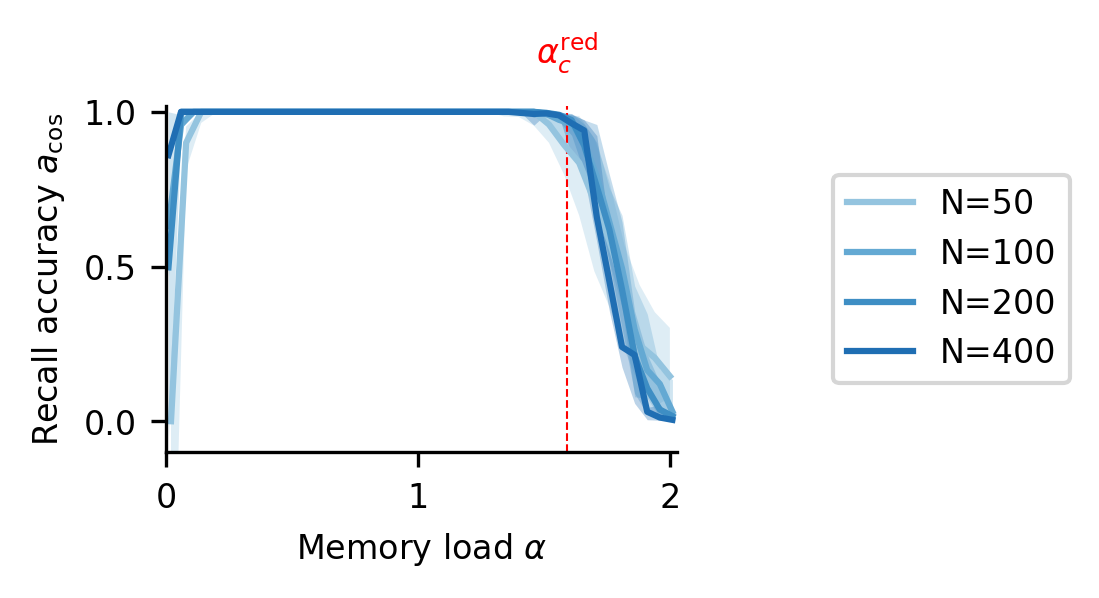

In [7]:
fig, ax = plt.subplots(1)
ax.set_prop_cycle(color=colormap_seq)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')
ax.text(alpha_red, 1 + 0.12, r'$\alpha_c^{\mathrm{red}}$', ha='center', va='bottom', c='r')
ax.vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)

# N=50: trim trailing zeros from alpha
plotting.plot_mean_and_area(ax, alpha[0][0][:end_early], acc[0][:, :end_early],
                            label='N=50', quantile=0.9, median=True, mean_ax=0)
# N=100, 200, 400
for x, y, N, reps in zip(alpha[1:], acc[1:], neurons[1:], n_finished[1:]):
    plotting.plot_mean_and_area(ax, x[0], y[:reps],
                                label=f'N={N}', quantile=0.9, median=True, mean_ax=0)

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
ax.legend(loc='center right', bbox_to_anchor=(1.8, 0.5))

plotting.standard_look(ax, ticks=False)
# fig.savefig(f"{plot_path}/scaling_panelA.svg", bbox_inches='tight')
plt.show()

## Panel B: Effect of Weight Magnitude at N = 800

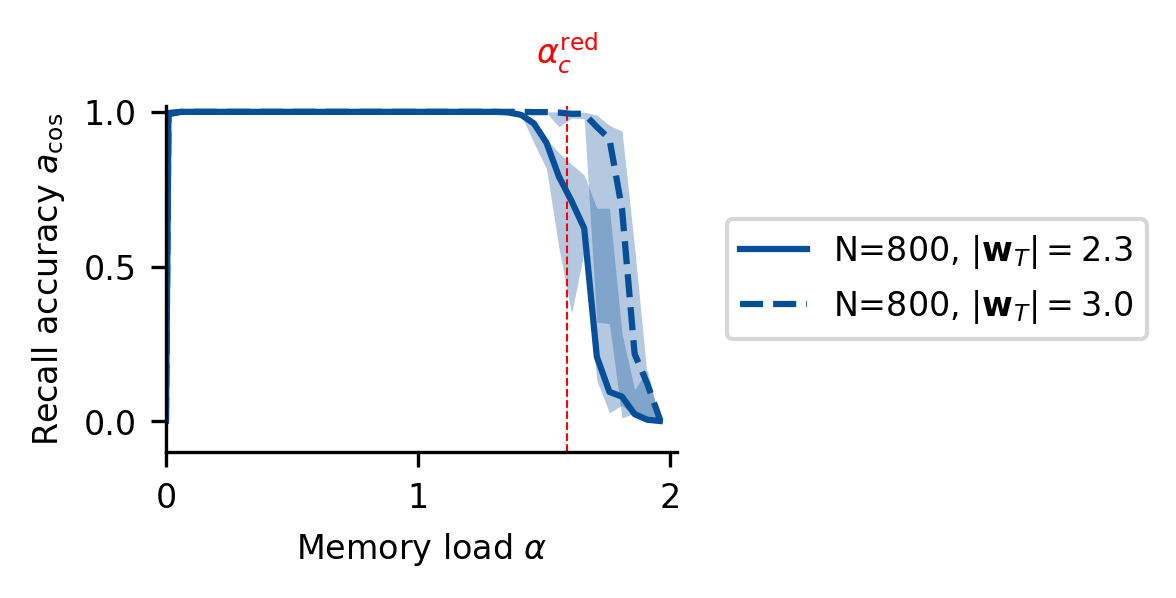

In [8]:
fig, ax = plt.subplots(1)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')
ax.text(alpha_red, 1 + 0.12, r'$\alpha_c^{\mathrm{red}}$', ha='center', va='bottom', c='r')
ax.vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)

# N=800: solid = |w_T|=2.3, dashed = |w_T|=3.0
# sort by alpha values (should be the same for both runs)
sort_idx = np.argsort(alpha_800)
alpha_800 = alpha_800[sort_idx]
acc_800_lo = acc_800_lo[:, sort_idx]
acc_800_hi = acc_800_hi[:, sort_idx]

plotting.plot_mean_and_area(ax, alpha_800, acc_800_lo,
                            label=r'N=800, $|\mathbf{w}_T|=2.3$',
                            quantile=0.9, median=True, mean_ax=0,
                            color=colormap_seq[-1])
plotting.plot_mean_and_area(ax, alpha_800, acc_800_hi,
                            label=r'N=800, $|\mathbf{w}_T|=3.0$',
                            quantile=0.9, median=True, mean_ax=0,
                            color=colormap_seq[-1], linestyle='--')

plotting.layout_performance(ax, (0, 2), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
ax.legend(loc='center right', bbox_to_anchor=(1.95, 0.5))
plotting.standard_look(ax, ticks=False)
# fig.savefig(f"{plot_path}/scaling_panelB.svg", bbox_inches='tight')
plt.show()

## Panel C: Noise Stability

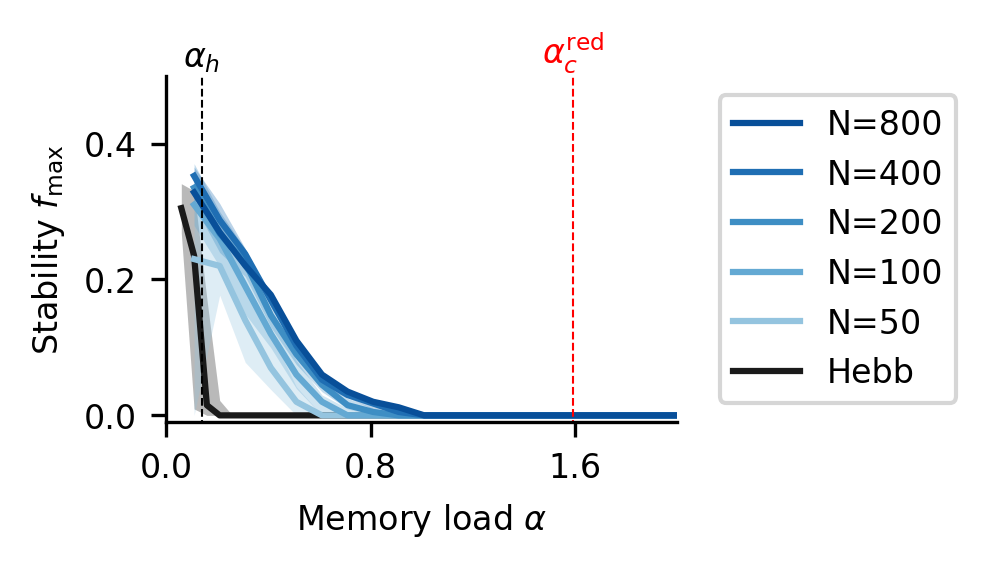

In [9]:
fig, ax = plt.subplots(1)
ax.set_xlabel(r'Memory load $\alpha$')
ax.set_ylabel(r'Stability $f_{\mathrm{max}}$')

# Hebb (black)
plotting.plot_mean_and_area(ax, x_hebb[1:], boundary_hebb[1:] / 100,
                            mean_ax=1, quantile=0.9, label='Hebb', median=True,
                            color='#1a1a1a')
# Infomorphic: N=50 (lightest) → N=800 (darkest)
ax.set_prop_cycle(color=colormap_seq)
for y, N in zip(boundaries_new, neurons_stab):
    plotting.plot_mean_and_area(ax, x2[1:], y[1:],
                                mean_ax=1, quantile=0.9, label=f'N={N}', median=True)

ax.vlines(alpha_h,   -0.1, 50.1, 'k', '--', linewidth=0.5)
ax.vlines(alpha_red, -0.1, 50.1, 'r', '--', linewidth=0.5)
ax.text(alpha_h,   0.5 + 0.002, r'$\alpha_h$',                  ha='center', va='bottom')
ax.text(alpha_red, 0.5 + 0.002, r'$\alpha_c^{\mathrm{red}}$',   ha='center', va='bottom', c='r')

plotting.layout_performance(ax, x_lim=(0, 2), y_lim=(0, 0.5), show_legend=True,
                            border_x=(0, 0), border_y=(0.01, 0.))
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels),
          loc='center left', bbox_to_anchor=(1.05, 0.5))
plotting.standard_look(ax)
# fig.savefig(f"{plot_path}/scaling_panelC.svg", bbox_inches='tight')
plt.show()

## Combined Figure (Panels A + B + C)

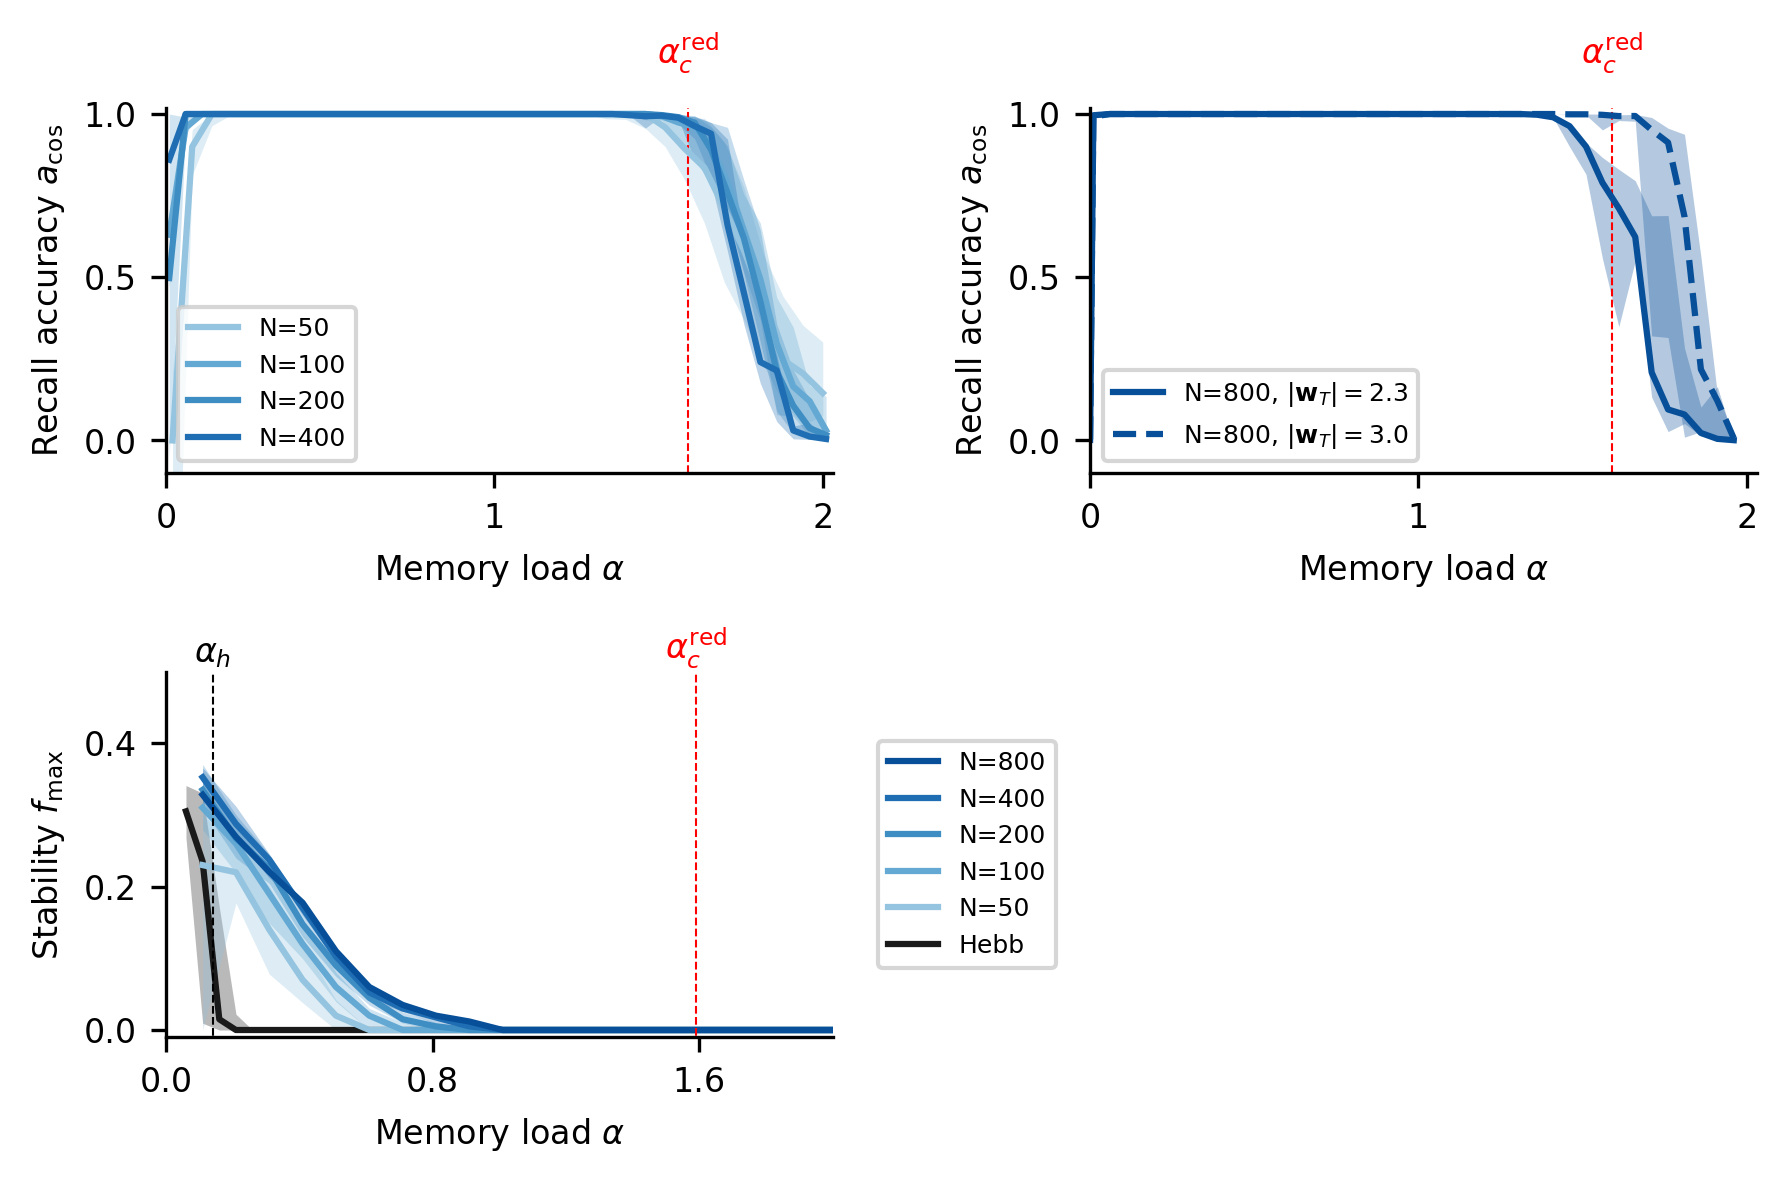

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(6, 4), dpi=300)

# ── Panel A ─────────────────────────────────────────────────────────────────
ax[0, 0].set_prop_cycle(color=colormap_seq)
ax[0, 0].set_xlabel(r'Memory load $\alpha$')
ax[0, 0].set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')
ax[0, 0].text(alpha_red, 1 + 0.12, r'$\alpha_c^{\mathrm{red}}$', ha='center', va='bottom', c='r')
ax[0, 0].vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)

plotting.plot_mean_and_area(ax[0, 0], alpha[0][0][:end_early], acc[0][:, :end_early],
                            label='N=50', quantile=0.9, median=True, mean_ax=0)
for x, y, N, reps in zip(alpha[1:], acc[1:], neurons[1:], n_finished[1:]):
    plotting.plot_mean_and_area(ax[0, 0], x[0], y[:reps],
                                label=f'N={N}', quantile=0.9, median=True, mean_ax=0)

plotting.layout_performance(ax[0, 0], (0, 2), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
ax[0, 0].legend(loc='lower left', fontsize=6)
plotting.standard_look(ax[0, 0], ticks=False)

# ── Panel B ─────────────────────────────────────────────────────────────────
ax[0, 1].set_xlabel(r'Memory load $\alpha$')
ax[0, 1].set_ylabel(r'Recall accuracy $a_{\mathrm{cos}}$')
ax[0, 1].text(alpha_red, 1 + 0.12, r'$\alpha_c^{\mathrm{red}}$', ha='center', va='bottom', c='r')
ax[0, 1].vlines(alpha_red, -0.1, 1.1, 'r', '--', linewidth=0.5)

plotting.plot_mean_and_area(ax[0, 1], alpha_800, acc_800_lo,
                            label=r'N=800, $|\mathbf{w}_T|=2.3$',
                            quantile=0.9, median=True, mean_ax=0, color=colormap_seq[-1])
plotting.plot_mean_and_area(ax[0, 1], alpha_800, acc_800_hi,
                            label=r'N=800, $|\mathbf{w}_T|=3.0$',
                            quantile=0.9, median=True, mean_ax=0,
                            color=colormap_seq[-1], linestyle='--')

plotting.layout_performance(ax[0, 1], (0, 2), x_log=False, show_legend=False,
                            border_x=(0, 0.03), border_y=(0.1, 0.02))
ax[0, 1].legend(loc='lower left', fontsize=6)
plotting.standard_look(ax[0, 1], ticks=False)

# ── Panel C ─────────────────────────────────────────────────────────────────
ax[1, 0].set_xlabel(r'Memory load $\alpha$')
ax[1, 0].set_ylabel(r'Stability $f_{\mathrm{max}}$')

plotting.plot_mean_and_area(ax[1, 0], x_hebb[1:], boundary_hebb[1:] / 100,
                            mean_ax=1, quantile=0.9, label='Hebb', median=True,
                            color='#1a1a1a')
ax[1, 0].set_prop_cycle(color=colormap_seq)
for y, N in zip(boundaries_new, neurons_stab):
    plotting.plot_mean_and_area(ax[1, 0], x2[1:], y[1:],
                                mean_ax=1, quantile=0.9, label=f'N={N}', median=True)

ax[1, 0].vlines(alpha_h,   -0.1, 50.1, 'k', '--', linewidth=0.5)
ax[1, 0].vlines(alpha_red, -0.1, 50.1, 'r', '--', linewidth=0.5)
ax[1, 0].text(alpha_h,   0.5 + 0.002, r'$\alpha_h$',                ha='center', va='bottom')
ax[1, 0].text(alpha_red, 0.5 + 0.002, r'$\alpha_c^{\mathrm{red}}$', ha='center', va='bottom', c='r')

plotting.layout_performance(ax[1, 0], x_lim=(0, 2), y_lim=(0, 0.5), show_legend=True,
                            border_x=(0, 0), border_y=(0.01, 0.))
handles, labels = ax[1, 0].get_legend_handles_labels()
ax[1, 0].legend(reversed(handles), reversed(labels),
            loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=6)
plotting.standard_look(ax[1, 0])

# Hide empty subplot (bottom right)
ax[1, 1].axis('off')

# fig.savefig(f"{plot_path}/scaling_combined.svg", bbox_inches='tight')
fig.tight_layout()
plt.show()